In [ ]:
!pip install transformers datasets accelerate

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from datasets import load_from_disk

ds = load_from_disk("/content/drive/MyDrive/DATN2026/dataset/reintel_final_dataset")
train_df = ds.to_pandas()

In [3]:
# from sklearn.model_selection import train_test_split

# train_df, val_df = train_test_split(
#     train_df,
#     test_size=0.2,
#     random_state=42,
#     stratify=train_df["label"]
# )
from sklearn.model_selection import train_test_split

# Bước 1: Tách 70% Train, còn lại 30% cho Val và Test
train_df, temp_df = train_test_split(
    train_df,
    test_size=0.3,          # 1.0 - 0.7 = 0.3
    random_state=42,
    stratify=train_df["label"]
)

# Bước 2: Tách 30% còn lại thành 2 phần bằng nhau (0.5 * 0.3 = 0.15)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # Chia đôi tập 30%
    random_state=42,
    stratify=temp_df["label"] # Đảm bảo stratify cả bước này
)

# Kiểm tra kết quả
print(f"Train size: {len(train_df)} ({len(train_df)/len(train_df)*100:.1f}%)") # Ví dụ kiểm tra tỉ lệ
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 3760 (100.0%)
Val size: 806
Test size: 806


In [4]:
from transformers import AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-large",use_fast=False)

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=256
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

    def __len__(self):
        return len(self.labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-large",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [6]:
train_df = train_df.dropna(subset=["post_message", "label"])
val_df = val_df.dropna(subset=["post_message", "label"])
test_df = test_df.dropna(subset=["post_message", "label"])

In [7]:
train_texts = train_df["post_message"].astype(str).tolist()
train_labels = train_df["label"].tolist()

val_texts = val_df["post_message"].astype(str).tolist()
val_labels = val_df["label"].tolist()

test_texts = test_df["post_message"].astype(str).tolist()
test_labels = test_df["label"].tolist()

In [8]:
train_dataset = TextDataset(train_texts, train_labels)
val_dataset = TextDataset(val_texts, val_labels)
test_dataset = TextDataset(test_texts, test_labels)

In [ ]:
# import numpy as np
# from sklearn.metrics import precision_recall_curve, f1_score

# BEST_THRESHOLD = 0.4

# def find_best_threshold(logits, labels):
#     probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

#     precision, recall, thresholds = precision_recall_curve(labels, probs)

#     f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
#     F2 = (5 * precision * recall) / (4 * precision + recall)

#     best_idx = np.argmax(f1_scores)

#     return thresholds[max(best_idx-1, 0)], f1_scores[best_idx]

In [9]:
from sklearn.metrics import accuracy_score, precision_recall_curve, precision_recall_fscore_support
import numpy as np
import torch

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

    precision, recall, thresholds = precision_recall_curve(labels, probs)

    f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    preds = (probs > best_threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "best_threshold": best_threshold
    }


In [10]:
import torch.nn as nn
import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     def __init__(self, weights, gamma=2.0):
#         super().__init__()
#         # weights: tensor [1.0, 5.0] đã tính từ tập train
#         self.register_buffer('weights', weights)
#         self.gamma = gamma

#     def forward(self, logits, targets):
#         ce_loss = F.cross_entropy(logits, targets, reduction='none')
#         pt = torch.exp(-ce_loss)
#         loss = (1 - pt) ** self.gamma * ce_loss
#         return loss.mean()
class FocalLoss(nn.Module):
    def __init__(self, weights=None, gamma=1.5):
        super().__init__()
        self.weights = weights
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')

        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce

        if self.weights is not None:
            w = self.weights.to(logits.device)
            focal = focal * w[targets]

        return focal.mean()
# import torch.nn.functional as F

# class HybridLoss(nn.Module):
#     def __init__(self, alpha=0.8, gamma=1.5):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma

#     def forward(self, logits, labels):
#         ce = F.cross_entropy(logits, labels, reduction="none")

#         pt = torch.exp(-ce)
#         focal = (1 - pt) ** self.gamma * ce

#         weights = torch.tensor([1.0, 5.0]).to(logits.device)  # boost fake news
#         weighted = weights[labels] * focal

#         return weighted.mean()

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# class_weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.unique(train_labels),
#     y=train_labels
# )

# class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = torch.tensor([1.0, 2.5], dtype=torch.float)
# class_weights[1] *= 2

In [12]:
from torch.nn import CrossEntropyLoss
from transformers import Trainer
from transformers import Trainer

# class SOTATrainer(Trainer):
#     def __init__(self, *args, loss_fn=None, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.loss_fn = loss_fn

#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")

#         outputs = model(**inputs)
#         logits = outputs["logits"]

#         loss = self.loss_fn(logits, labels)

#         return (loss, outputs) if return_outputs else loss
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = FocalLoss(weights=class_weights, gamma=1.5)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss = self.loss_fct(
            logits.view(-1, logits.shape[-1]),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [13]:
from transformers import Trainer, TrainingArguments
from transformers import EarlyStoppingCallback
args = TrainingArguments(
    output_dir="./phobert",
    learning_rate=1e-6,
    warmup_steps=0.1,
    max_grad_norm=1.0,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,

    logging_steps=100,
    eval_steps=100,
    save_steps=100,

    eval_strategy="steps",
    logging_strategy="steps",
    save_strategy="steps",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2
)
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Best Threshold
100,0.245568,0.242079,0.766749,0.628458,0.646341,0.611538,0.497295
200,0.236539,0.228082,0.847395,0.694789,0.979021,0.538462,0.477728
300,0.206560,0.194799,0.851117,0.701493,0.992958,0.542308,0.440495
400,0.163676,0.146679,0.851117,0.726027,0.893258,0.611538,0.388520
500,0.120921,0.148412,0.843672,0.766667,0.739286,0.796154,0.242760
600,0.121124,0.129350,0.877171,0.803181,0.831276,0.776923,0.320330
700,0.109272,0.129565,0.885856,0.816733,0.847107,0.788462,0.313041
800,0.102078,0.116759,0.887097,0.825336,0.823755,0.826923,0.316557
900,0.096513,0.113682,0.895782,0.835938,0.849206,0.823077,0.346037
1000,0.085932,0.124349,0.898263,0.837945,0.861789,0.815385,0.301144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2300, training_loss=0.1162666358118472, metrics={'train_runtime': 6040.2174, 'train_samples_per_second': 3.112, 'train_steps_per_second': 0.389, 'total_flos': 8573768542617600.0, 'train_loss': 0.1162666358118472, 'epoch': 4.8936170212765955})

In [14]:
trainer.save_model("phobert_text_best")
tokenizer.save_pretrained("phobert_text_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('phobert_text_best/tokenizer_config.json',
 'phobert_text_best/vocab.txt',
 'phobert_text_best/bpe.codes',
 'phobert_text_best/added_tokens.json')

In [15]:
history = trainer.state.log_history
import pandas as pd

df_log = pd.DataFrame(history)
df_log = df_log.fillna(method="ffill")

/tmp/ipykernel_4619/717795887.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_log = df_log.fillna(method="ffill")


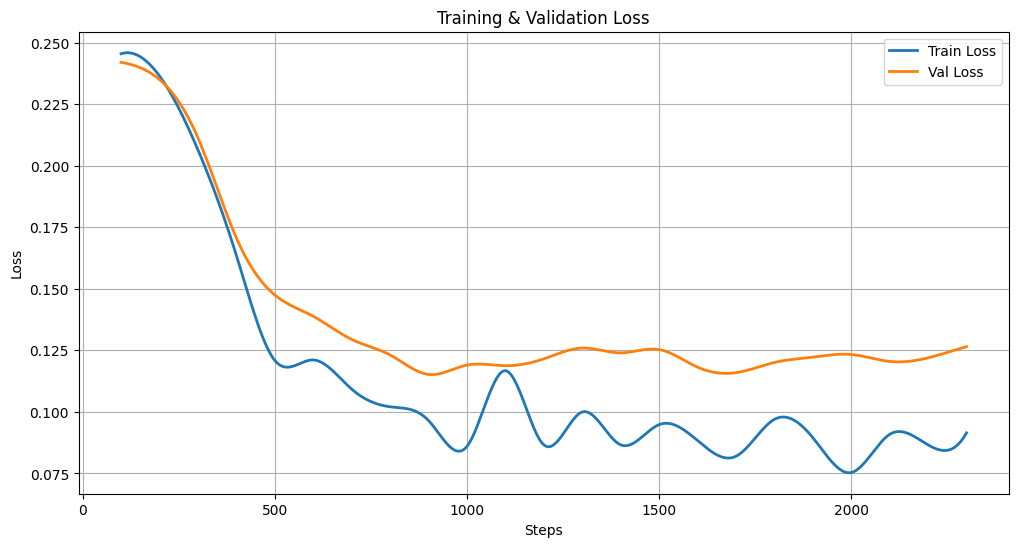

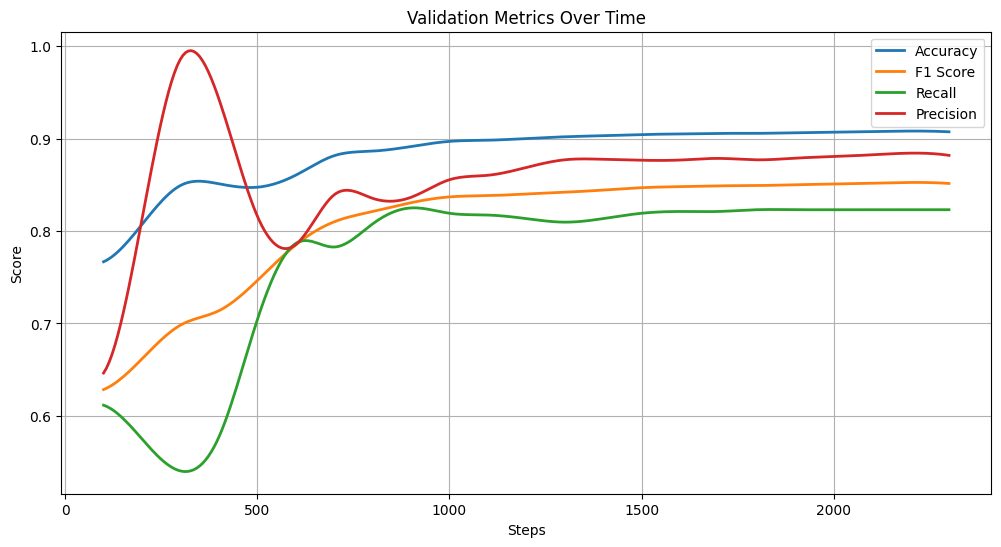

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
import pandas as pd

def plot_smooth(x, y, label):
    # Loại bỏ NaN và xử lý duplicate step
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    df = df.groupby('x')['y'].mean().reset_index()

    x_clean = df['x'].values
    y_clean = df['y'].values

    if len(x_clean) > 3:
        x_smooth = np.linspace(x_clean.min(), x_clean.max(), 300)
        spl = make_interp_spline(x_clean, y_clean, k=3)
        plt.plot(x_smooth, spl(x_smooth), label=label, linewidth=2)
    else:
        plt.plot(x_clean, y_clean, marker='o', label=label)

# ==============================
# 1. TRAINING & VALIDATION LOSS
# ==============================
plt.figure(figsize=(12, 6))

# Train Loss
train_loss = df_log[df_log["loss"].notna()]
plot_smooth(
    train_loss["step"].values,
    train_loss["loss"].values,
    "Train Loss"
)

# Validation Loss
if "eval_loss" in df_log.columns:
    val_loss = df_log[df_log["eval_loss"].notna()]
    plot_smooth(
        val_loss["step"].values,
        val_loss["eval_loss"].values,
        "Val Loss"
    )

plt.title("Training & Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# ============================
# 2. VALIDATION PERFORMANCE
# ============================
plt.figure(figsize=(12, 6))

# Accuracy
if "eval_accuracy" in df_log.columns:
    eval_acc = df_log[df_log["eval_accuracy"].notna()]
    plot_smooth(
        eval_acc["step"].values,
        eval_acc["eval_accuracy"].values,
        "Accuracy"
    )

# F1 Score
if "eval_f1" in df_log.columns:
    eval_f1 = df_log[df_log["eval_f1"].notna()]
    plot_smooth(
        eval_f1["step"].values,
        eval_f1["eval_f1"].values,
        "F1 Score"
    )

# Recall
if "eval_recall" in df_log.columns:
    eval_recall = df_log[df_log["eval_recall"].notna()]
    plot_smooth(
        eval_recall["step"].values,
        eval_recall["eval_recall"].values,
        "Recall"
    )

# Precision
if "eval_precision" in df_log.columns:
    eval_precision = df_log[df_log["eval_precision"].notna()]
    plot_smooth(
        eval_precision["step"].values,
        eval_precision["eval_precision"].values,
        "Precision"
    )

# Tự động scale trục Y
metric_cols = ["eval_accuracy", "eval_f1", "eval_recall", "eval_precision"]
available_metrics = [col for col in metric_cols if col in df_log.columns]

all_values = []
for col in available_metrics:
    all_values.extend(df_log[col].dropna().values)

if all_values:
    y_min = min(all_values)
    y_max = max(all_values)
    buffer = (y_max - y_min) * 0.05 if y_max != y_min else 0.05
    plt.ylim(y_min - buffer, y_max + buffer)

plt.title("Validation Metrics Over Time")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Best Threshold
100,0.347647,0.189741,0.868486,0.791339,0.810484,0.773077,0.521858
200,0.140001,0.103136,0.906948,0.838710,0.951220,0.750000,0.499982


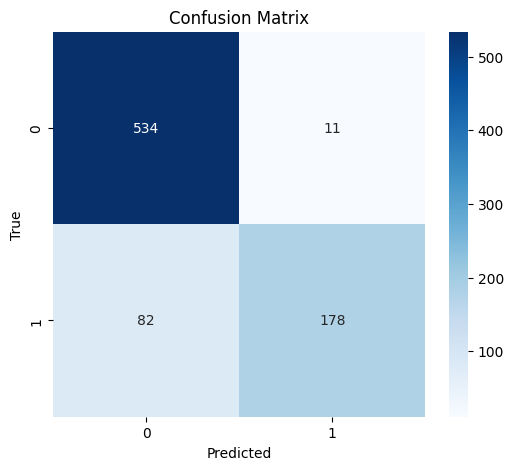

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       545
           1       0.94      0.68      0.79       260

    accuracy                           0.88       805
   macro avg       0.90      0.83      0.86       805
weighted avg       0.89      0.88      0.88       805



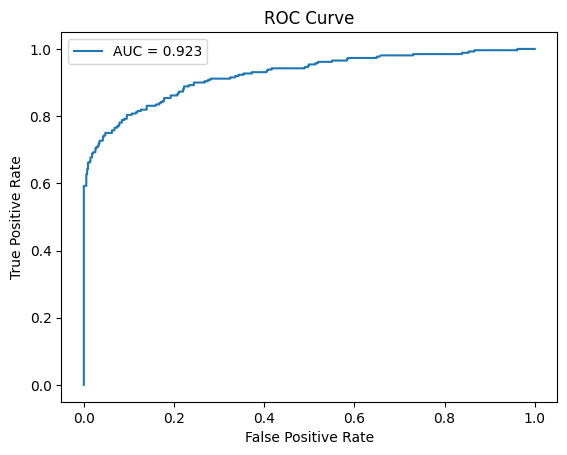

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_dataset)

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,        # 🔥 hiện số
    fmt="d",
    cmap="Blues"       # 🔵 màu xanh
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

from sklearn.metrics import roc_curve, auc

probs = preds.predictions[:, 1]

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [30]:
import numpy as np
import pandas as pd

def prepare_meta(df):
    # ===== convert numeric =====
    for col in ["num_like_post", "num_comment_post", "num_share_post"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        df[col] = np.log1p(df[col])

    # ===== time =====
    df["datetime"] = pd.to_datetime(df["timestamp_post"], unit="s")

    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month

    # ===== cyclical =====
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["day_sin"] = np.sin(2*np.pi*df["day"]/7)
    df["day_cos"] = np.cos(2*np.pi*df["day"]/7)

    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

    return df

train_df = prepare_meta(train_df)
val_df = prepare_meta(val_df)
test_df = prepare_meta(test_df)

In [31]:
meta_cols = [
    "num_like_post",
    "num_comment_post",
    "num_share_post",
    "hour_sin", "hour_cos",
    "day_sin", "day_cos",
    "month_sin", "month_cos"
]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_meta = scaler.fit_transform(train_df[meta_cols])
val_meta = scaler.transform(val_df[meta_cols])
test_meta = scaler.transform(test_df[meta_cols])

In [33]:
train_meta = np.nan_to_num(train_meta, nan=0.0, posinf=0.0, neginf=0.0)
val_meta = np.nan_to_num(val_meta, nan=0.0, posinf=0.0, neginf=0.0)
test_meta = np.nan_to_num(test_meta, nan=0.0, posinf=0.0, neginf=0.0)

In [34]:
from PIL import Image
import io
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("phobert_text_best")

class MultiDataset(torch.utils.data.Dataset):
    def __init__(self, df, meta, labels):
        self.df = df
        self.meta = meta
        self.labels = labels

        self.encodings = tokenizer(
            df["post_message"].astype(str).tolist(),
            truncation=True,
            padding="max_length",
            max_length=256
        )

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

        # ===== IMAGE =====
        img_data = self.df.iloc[idx]["image_0"]

        if isinstance(img_data, dict) and "bytes" in img_data:
            img = Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
        else:
            # fallback nếu không có ảnh
            img = Image.new("RGB", (224, 224))

        item["image"] = transform(img)

        # ===== META =====
        item["meta"] = torch.tensor(self.meta[idx], dtype=torch.float)

        # ===== LABEL =====
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

    def __len__(self):
        return len(self.labels)

In [36]:
train_dataset = MultiDataset(train_df, train_meta, train_df["label"].tolist())
val_dataset = MultiDataset(val_df, val_meta, val_df["label"].tolist())
test_dataset = MultiDataset(test_df, test_meta, test_df["label"].tolist())

In [37]:
import torch.nn as nn
from transformers import AutoModel
import torchvision.models as models

class MultiModel(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()

        # ===== TEXT =====
        self.text_model = AutoModel.from_pretrained("phobert_text_best")

        # 🔥 freeze 2 layer đầu
        for name, param in self.text_model.named_parameters():
            if "encoder.layer.0" in name or "encoder.layer.1" in name:
                param.requires_grad = False

        # ===== IMAGE =====
        self.image_model = models.resnet18(pretrained=True)
        self.image_model.fc = nn.Linear(512, 128)

        # ===== META =====
        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32)
        )

        # 🔥 GATING
        self.gate = nn.Sequential(
            nn.Linear(1024 + 128 + 32, 3),
            nn.Softmax(dim=1)
        )

        # ===== CLASSIFIER =====
        self.classifier = nn.Sequential(
            nn.Linear(1024 + 128 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

        self.norm = nn.LayerNorm(1024 + 128 + 32)

    def forward(self, input_ids=None, attention_mask=None, meta=None, image=None, labels=None):

        text_out = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        cls = text_out.last_hidden_state[:, 0]

        img_feat = self.image_model(image)
        meta_feat = self.meta_fc(meta)

        features = torch.cat([cls, img_feat, meta_feat], dim=1)

        weights = self.gate(features)

        # 🔥 fix gating
        w_text = weights[:,0].unsqueeze(1) * 0.5 + 0.5
        w_img  = weights[:,1].unsqueeze(1) * 0.5
        w_meta = weights[:,2].unsqueeze(1) * 0.5

        cls = cls * w_text
        img_feat = img_feat * w_img
        meta_feat = meta_feat * w_meta

        x = torch.cat([cls, img_feat, meta_feat], dim=1)
        x = self.norm(x)

        logits = self.classifier(x)

        return {"logits": logits}

In [38]:
model = MultiModel(meta_dim=len(meta_cols))

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: phobert_text_best
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'we

In [39]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Best Threshold
100,0.273324,0.172139,0.883375,0.790179,0.941489,0.680769,0.487765
200,0.162094,0.110980,0.895782,0.835294,0.852000,0.819231,0.362480
300,0.092608,0.117513,0.903226,0.843373,0.882353,0.807692,0.365786
400,0.101707,0.135655,0.904467,0.845691,0.882845,0.811538,0.322824
500,0.084150,0.157316,0.904467,0.845691,0.882845,0.811538,0.237547
600,0.101267,0.156123,0.904467,0.845070,0.886076,0.807692,0.265595


TrainOutput(global_step=600, training_loss=0.13585814158121745, metrics={'train_runtime': 1351.1012, 'train_samples_per_second': 13.915, 'train_steps_per_second': 1.739, 'total_flos': 0.0, 'train_loss': 0.13585814158121745, 'epoch': 1.2765957446808511})

In [40]:
history = trainer.state.log_history
import pandas as pd

df_log = pd.DataFrame(history)
df_log = df_log.fillna(method="ffill")

/tmp/ipykernel_4619/717795887.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_log = df_log.fillna(method="ffill")


In [41]:
import torch
import os

def save_model_to_drive(model, tokenizer, scaler, meta_cols, drive_filename):
    # Đường dẫn thư mục đích trên Drive (ví dụ trong folder DATN2026)
    save_dir = "/content/drive/MyDrive/DATN2026/models"

    # Tạo folder nếu chưa tồn tại
    os.makedirs(save_dir, exist_ok=True)

    # Đường dẫn đầy đủ
    full_path = os.path.join(save_dir, drive_filename)

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'meta_cols': meta_cols,
        'tokenizer_config': tokenizer,
        'scaler': scaler
    }

    torch.save(checkpoint, full_path)
    print(f"✅ Model đã được lưu an toàn tại Drive: {full_path}")

# Cách dùng:
save_model_to_drive(model, tokenizer, scaler, meta_cols, "reintel_final_model.pth")

✅ Model đã được lưu an toàn tại Drive: /content/drive/MyDrive/DATN2026/models/reintel_final_model.pth


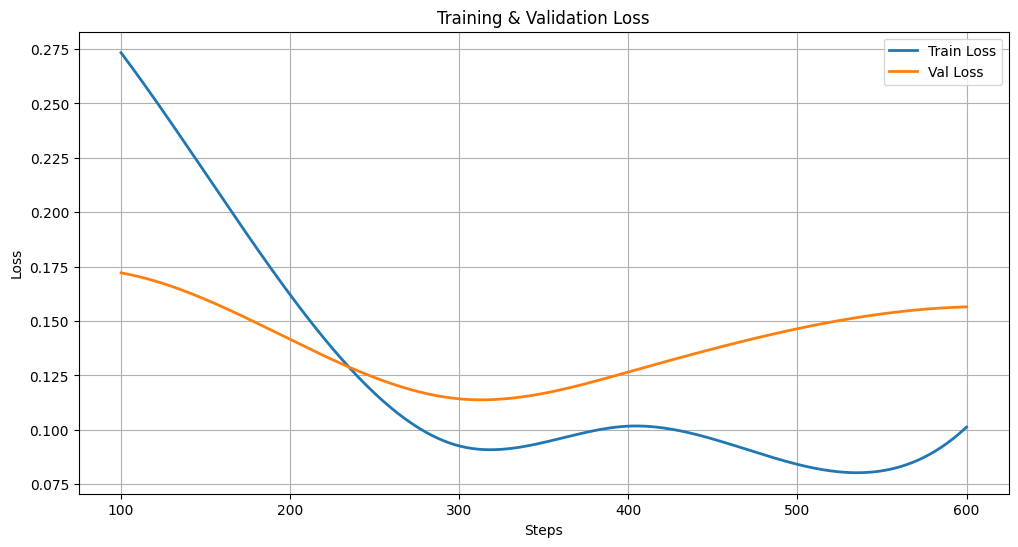

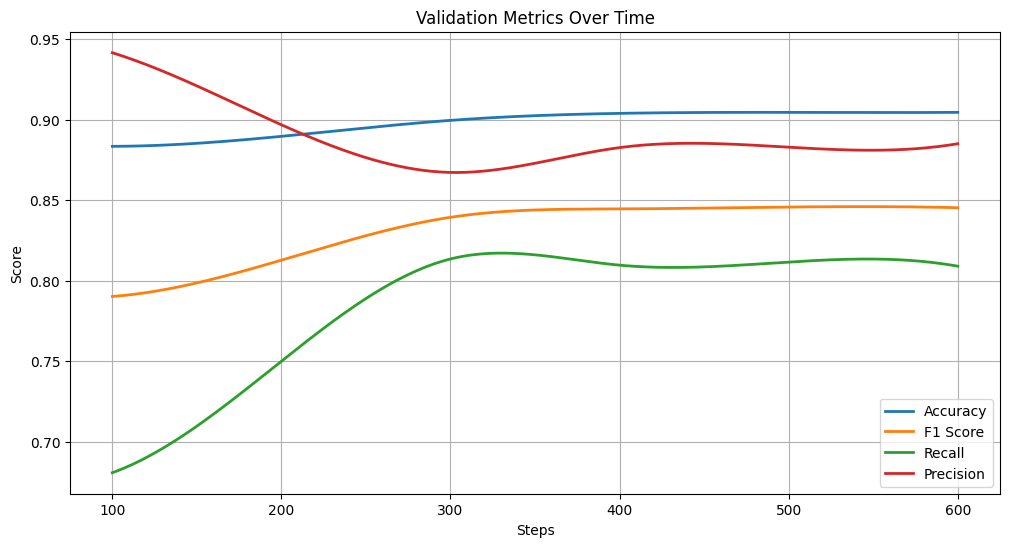

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
import pandas as pd

def plot_smooth(x, y, label):
    # Loại bỏ NaN và xử lý duplicate step
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    df = df.groupby('x')['y'].mean().reset_index()

    x_clean = df['x'].values
    y_clean = df['y'].values

    if len(x_clean) > 3:
        x_smooth = np.linspace(x_clean.min(), x_clean.max(), 300)
        spl = make_interp_spline(x_clean, y_clean, k=3)
        plt.plot(x_smooth, spl(x_smooth), label=label, linewidth=2)
    else:
        plt.plot(x_clean, y_clean, marker='o', label=label)

# ==============================
# 1. TRAINING & VALIDATION LOSS
# ==============================
plt.figure(figsize=(12, 6))

# Train Loss
train_loss = df_log[df_log["loss"].notna()]
plot_smooth(
    train_loss["step"].values,
    train_loss["loss"].values,
    "Train Loss"
)

# Validation Loss
if "eval_loss" in df_log.columns:
    val_loss = df_log[df_log["eval_loss"].notna()]
    plot_smooth(
        val_loss["step"].values,
        val_loss["eval_loss"].values,
        "Val Loss"
    )

plt.title("Training & Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# ============================
# 2. VALIDATION PERFORMANCE
# ============================
plt.figure(figsize=(12, 6))

# Accuracy
if "eval_accuracy" in df_log.columns:
    eval_acc = df_log[df_log["eval_accuracy"].notna()]
    plot_smooth(
        eval_acc["step"].values,
        eval_acc["eval_accuracy"].values,
        "Accuracy"
    )

# F1 Score
if "eval_f1" in df_log.columns:
    eval_f1 = df_log[df_log["eval_f1"].notna()]
    plot_smooth(
        eval_f1["step"].values,
        eval_f1["eval_f1"].values,
        "F1 Score"
    )

# Recall
if "eval_recall" in df_log.columns:
    eval_recall = df_log[df_log["eval_recall"].notna()]
    plot_smooth(
        eval_recall["step"].values,
        eval_recall["eval_recall"].values,
        "Recall"
    )

# Precision
if "eval_precision" in df_log.columns:
    eval_precision = df_log[df_log["eval_precision"].notna()]
    plot_smooth(
        eval_precision["step"].values,
        eval_precision["eval_precision"].values,
        "Precision"
    )

# Tự động scale trục Y
metric_cols = ["eval_accuracy", "eval_f1", "eval_recall", "eval_precision"]
available_metrics = [col for col in metric_cols if col in df_log.columns]

all_values = []
for col in available_metrics:
    all_values.extend(df_log[col].dropna().values)

if all_values:
    y_min = min(all_values)
    y_max = max(all_values)
    buffer = (y_max - y_min) * 0.05 if y_max != y_min else 0.05
    plt.ylim(y_min - buffer, y_max + buffer)

plt.title("Validation Metrics Over Time")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

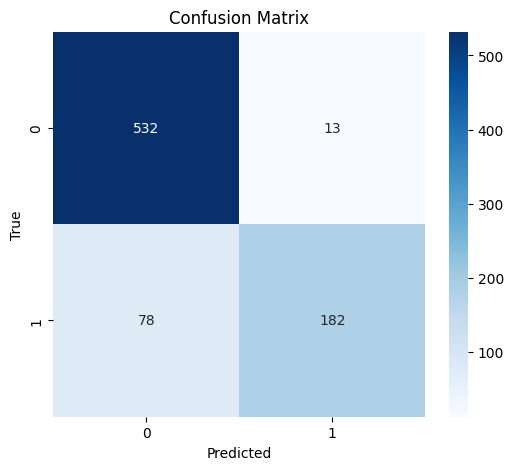

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       545
           1       0.93      0.70      0.80       260

    accuracy                           0.89       805
   macro avg       0.90      0.84      0.86       805
weighted avg       0.89      0.89      0.88       805



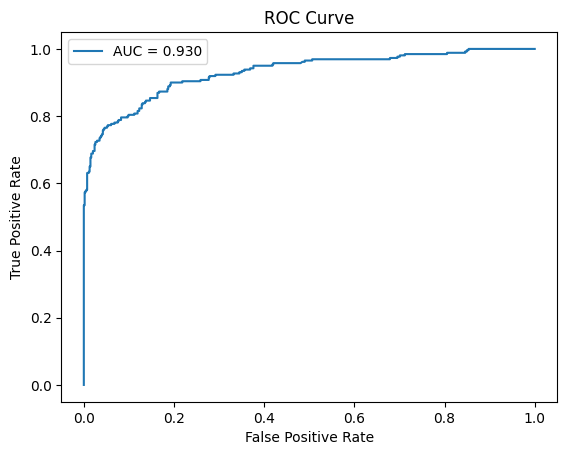

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_dataset)

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,        # 🔥 hiện số
    fmt="d",
    cmap="Blues"       # 🔵 màu xanh
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

from sklearn.metrics import roc_curve, auc

probs = preds.predictions[:, 1]

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
def load_model_full(path="/content/drive/MyDrive/DATN2026/models/reintel_final_model.pth"):
    # Load checkpoint
    checkpoint = torch.load(path, map_location=torch.device('cpu'))

    # Lấy thông tin từ checkpoint
    meta_cols = checkpoint['meta_cols']
    scaler = checkpoint['scaler']
    tokenizer = checkpoint['tokenizer_config']

    # Khởi tạo model và nạp weights
    model = MultiModel(meta_dim=len(meta_cols)) # meta_dim được lấy tự động từ meta_cols
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    return model, tokenizer, scaler, meta_cols